In [1]:
!pip install "dask[distributed]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import sqrt
import matplotlib.ticker as mticker

import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

# plt.style.use('seaborn-v0_8')
# plotColors = (list(mcolors.TABLEAU_COLORS)*3)[:23]

In [3]:
%pip install distributed

Starting Dask Client

In [4]:
cluster = LocalCluster()
client = Client(cluster)
print(client)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:34429
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41697'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43767'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34051 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34051
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:57542
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42703 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42703
INFO:distributed.core:Starting established connection to tcp://127

<Client: 'tcp://127.0.0.1:34429' processes=2 threads=2, memory=12.67 GiB>


In [6]:
# Downloading and loading dataset from drive
from google.colab import drive
drive.mount('/content/drive')

!wget -O "/content/drive/MyDrive/Crimes.csv" "https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD"

DATA_PATH = "/content/drive/MyDrive/Crimes.csv"

Mounted at /content/drive
--2026-04-02 19:58:00--  https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD
Resolving data.cityofchicago.org (data.cityofchicago.org)... 52.206.140.199, 52.206.140.205, 52.206.68.26
Connecting to data.cityofchicago.org (data.cityofchicago.org)|52.206.140.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘/content/drive/MyDrive/Crimes.csv’

/content/drive/MyDr     [              <=>   ]   1.88G   812KB/s    in 43m 15s 

2026-04-02 20:41:16 (758 KB/s) - ‘/content/drive/MyDrive/Crimes.csv’ saved [2014836075]



In [7]:

allCrimes = dd.read_csv(
    DATA_PATH,
    dtype={
        'X Coordinate': 'float64',
        'Y Coordinate': 'float64',
        'Ward': 'float64',
        'Community Area': 'float64',
        'District': 'float64',
        'FBI Code':'object',
        'IUCR':'object',
        'ID':'object'
    },
    assume_missing=True
)

print(allCrimes.dtypes)
print("Partitions:", allCrimes.npartitions)

ID                      string[pyarrow]
Case Number             string[pyarrow]
Date                    string[pyarrow]
Block                   string[pyarrow]
IUCR                    string[pyarrow]
Primary Type            string[pyarrow]
Description             string[pyarrow]
Location Description    string[pyarrow]
Arrest                             bool
Domestic                           bool
Beat                            float64
District                        float64
Ward                            float64
Community Area                  float64
FBI Code                string[pyarrow]
X Coordinate                    float64
Y Coordinate                    float64
Year                            float64
Updated On              string[pyarrow]
Latitude                        float64
Longitude                       float64
Location                string[pyarrow]
dtype: object
Partitions: 31


In [8]:
# Removing duplicates
allCrimes = allCrimes.map_partitions(lambda df: df.drop_duplicates(subset="ID"))
print("Dedup done — no cross-partition shuffle needed")

Dedup done — no cross-partition shuffle needed


In [9]:
# Removing NaN values
#(removing entire row if a NaN value is present)
allCrimes = allCrimes.dropna()
print("Records after dropping NaN:", len(allCrimes))

Records after dropping NaN: 7810600


In [10]:
# Removing invalid coordinates
#(remove where coordinates are 0, they are clearly wring/missing)


allCrimes = allCrimes[
    (allCrimes['X Coordinate'] != 0) &
    (allCrimes['Y Coordinate'] != 0) &
    (allCrimes['Longitude'] != 0) &
    (allCrimes['Latitude'] != 0)
]
print("Records after removing bad locations:", len(allCrimes))

Records after removing bad locations: 7810490


In [11]:
# convert date column from string to object
allCrimes['Date'] = dd.to_datetime(allCrimes['Date'], format='%m/%d/%Y %I:%M:%S %p')

In [12]:
# extracting time features from date
allCrimes['Hour']      = allCrimes['Date'].dt.hour
allCrimes['Month']     = allCrimes['Date'].dt.month
allCrimes['DayOfWeek'] = allCrimes['Date'].dt.dayofweek
allCrimes['Year']      = allCrimes['Date'].dt.year

In [13]:
# keep top 25 crime locations
# Compute value counts (this triggers execution)
loc_counts = allCrimes['Location Description'].value_counts().compute()
mostFrequentLocations = list(loc_counts[:25].index)

# Replace rare locations with 'OTHER'
allCrimes['Location Description'] = allCrimes['Location Description'].where(
    allCrimes['Location Description'].isin(mostFrequentLocations),
    other='OTHER'
)

# Same for Description column
desc_counts = allCrimes['Description'].value_counts().compute()
mostFrequentDescription = list(desc_counts[:25].index)

allCrimes['Description'] = allCrimes['Description'].where(
    allCrimes['Description'].isin(mostFrequentDescription),
    other='OTHER'
)

In [14]:
# convert to categorical for increasing speed
allCrimes['Primary Type']         = allCrimes['Primary Type'].astype('category')
allCrimes['Location Description'] = allCrimes['Location Description'].astype('category')
allCrimes['Description']          = allCrimes['Description'].astype('category')

In [15]:
# drop unnecessary columns
allCrimes = allCrimes.drop(
    columns=['Case Number', 'IUCR', 'Updated On', 'FBI Code', 'Beat', 'Ward'],
    errors='ignore'
)

In [16]:
# THIS is where all the above lazy steps actually execute (this is lazy evaluation of Dask)
allCrimes = allCrimes.compute()

print("Final clean dataset shape:", allCrimes.shape)
allCrimes.head()

Final clean dataset shape: (7810490, 19)


,ID,Date,Block,Primary Type,Description,Location Description,Arrest,Domestic,District,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Location,Hour,Month,DayOfWeek
2,12131221,2020-08-10 09:45:00,015XX N DAMEN AVE,ROBBERY,OTHER,OTHER,True,False,14.0,24.0,1162795.0,1909900.0,2020,41.908418,-87.677407,"(41.908417822, -87.67740693)",9,8,0
4,13203321,2023-09-06 17:00:00,002XX N Wells st,CRIMINAL DAMAGE,OTHER,OTHER,False,False,1.0,32.0,1174694.0,1901831.0,2023,41.886018,-87.633938,"(41.886018055, -87.633937881)",17,9,2
5,13204489,2023-09-06 11:00:00,0000X E 8TH ST,THEFT,OTHER,OTHER,False,False,1.0,32.0,1176857.0,1896680.0,2023,41.871835,-87.626151,"(41.871834768, -87.62615082)",11,9,2
6,11695116,2019-05-21 08:20:00,018XX S CALIFORNIA AVE,BURGLARY,OTHER,OTHER,False,False,10.0,29.0,1157982.0,1890961.0,2019,41.856547,-87.695605,"(41.856547057, -87.695604526)",8,5,1
7,12419690,2021-07-07 10:30:00,132XX S GREENWOOD AVE,SEX OFFENSE,OTHER,OTHER,False,False,5.0,54.0,1186051.0,1817781.0,2021,41.655116,-87.594883,"(41.65511579, -87.594883198)",10,7,2


In [17]:
4# creating a backup
backup = allCrimes.copy()

# **EXPLORATORY DATA ANALYSIS**

In [18]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

In [19]:
DAY_NAMES   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

**STATISTICAL** **SUMMARY**

In [20]:
print("\n--- Dataset shape ---")
print(f"Rows: {allCrimes.shape[0]:,}   Columns: {allCrimes.shape[1]}")


--- Dataset shape ---
Rows: 7,810,490   Columns: 19


In [21]:
print("\n--- Column names & types ---")
print(allCrimes.dtypes)


--- Column names & types ---
ID                      string[pyarrow]
Date                     datetime64[ns]
Block                   string[pyarrow]
Primary Type                   category
Description                    category
Location Description           category
Arrest                             bool
Domestic                           bool
District                        float64
Community Area                  float64
X Coordinate                    float64
Y Coordinate                    float64
Year                              int32
Latitude                        float64
Longitude                       float64
Location                string[pyarrow]
Hour                              int32
Month                             int32
DayOfWeek                         int32
dtype: object


In [22]:
print("\n--- Numeric columns summary ---")
print(allCrimes[['Year', 'Hour', 'Month', 'DayOfWeek',
                  'District', 'Community Area']].describe().round(2))



--- Numeric columns summary ---
             Year        Hour       Month   DayOfWeek    District  \
count  7810490.00  7810490.00  7810490.00  7810490.00  7810490.00   
mean      2011.93       13.07        6.61        3.00       11.28   
std          6.89        6.76        3.33        1.99        6.96   
min       2001.00        0.00        1.00        0.00        1.00   
25%       2006.00        9.00        4.00        1.00        6.00   
50%       2011.00       14.00        7.00        3.00       10.00   
75%       2018.00       19.00        9.00        5.00       17.00   
max       2026.00       23.00       12.00        6.00       31.00   

       Community Area  
count      7810490.00  
mean            37.38  
std             21.53  
min              0.00  
25%             23.00  
50%             32.00  
75%             56.00  
max             77.00  


In [23]:
print("\n--- Primary Type (top 10 most frequent) ---")
print(allCrimes['Primary Type'].value_counts().head(10))


--- Primary Type (top 10 most frequent) ---
Primary Type
THEFT                  1667072
BATTERY                1428647
CRIMINAL DAMAGE         893244
NARCOTICS               687667
ASSAULT                 531114
OTHER OFFENSE           488368
BURGLARY                416081
MOTOR VEHICLE THEFT     402578
DECEPTIVE PRACTICE      345485
ROBBERY                 292165
Name: count, dtype: int64


In [24]:
print("\n--- Location Description (top 10) ---")
print(allCrimes['Location Description'].value_counts().head(10))


--- Location Description (top 10) ---
Location Description
OTHER                             7447440
PARKING LOT/GARAGE(NON.RESID.)     181671
DRUG STORE                          36829
CHA APARTMENT                       33058
BANK                                30177
CTA BUS                             26235
RESIDENCE - PORCH / HALLWAY         18840
BARBERSHOP                           8254
MEDICAL/DENTAL OFFICE                6619
FACTORY/MANUFACTURING BUILDING       5957
Name: count, dtype: int64


In [25]:
print("\n--- Arrest rate ---")
print(f"{allCrimes['Arrest'].mean() * 100:.1f}% of crimes led to an arrest")


--- Arrest rate ---
24.8% of crimes led to an arrest


In [26]:
print("\n--- Domestic crime rate ---")
print(f"{allCrimes['Domestic'].mean() * 100:.1f}% of crimes were domestic")


--- Domestic crime rate ---
17.4% of crimes were domestic


In [27]:
print("\n--- Year range ---")
print(f"Data spans: {int(allCrimes['Year'].min())} to {int(allCrimes['Year'].max())}")


--- Year range ---
Data spans: 2001 to 2026


In [28]:
print("\n--- Missing values after cleaning ---")
print(allCrimes.isnull().sum())


--- Missing values after cleaning ---
ID                      0
Date                    0
Block                   0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
District                0
Community Area          0
X Coordinate            0
Y Coordinate            0
Year                    0
Latitude                0
Longitude               0
Location                0
Hour                    0
Month                   0
DayOfWeek               0
dtype: int64


**UNIVARIATE ANALYSIS**

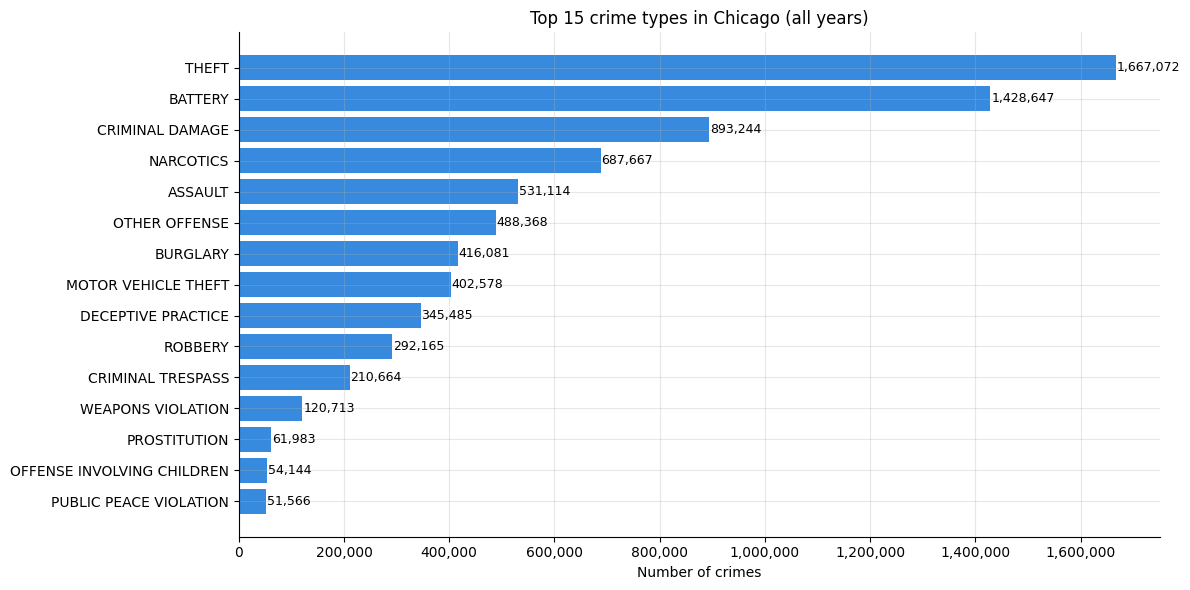

In [29]:
#Top 15 Crime Types
top_crimes = allCrimes['Primary Type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_crimes.index[::-1],
    top_crimes.values[::-1],
    color='#378ADD'
)
ax.set_xlabel('Number of crimes')
ax.set_title('Top 15 crime types in Chicago (all years)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, top_crimes.values[::-1]):
    ax.text(bar.get_width() + 2000,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot01_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()

Theft is the most frequently reported crime in Chicago with 1,667,072 cases,
followed by Battery at 1,428,647. Ttogether these two account for a disproportionately
large share of all recorded crimes. Criminal Damage and Narcotics rank third and fourth
respectively, while crimes like Prostitution and Public Peace Violation appear
significantly less frequent, suggesting crime in Chicago is heavily concentrated
in a few dominant categories.

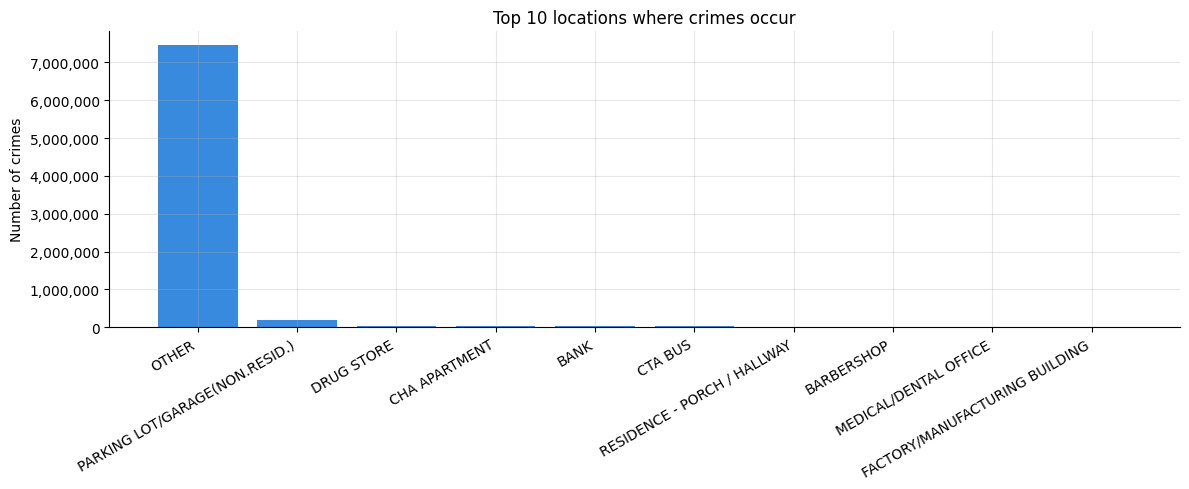

In [30]:
#Top 10 Location Types
loc_counts = allCrimes['Location Description'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(loc_counts)), loc_counts.values, color='#378ADD')
ax.set_xticks(range(len(loc_counts)))
ax.set_xticklabels(loc_counts.index, rotation=30, ha='right')
ax.set_ylabel('Number of crimes')
ax.set_title('Top 10 locations where crimes occur')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot02_location_types.png', dpi=150, bbox_inches='tight')
plt.show()

The overwhelming majority of crimes fall under the 'OTHER' category (~7.5 million),
which is a result of the preprocessing step that consolidated less frequent location
types into a single label. Among specifically identified locations, Parking Lot/Garage
is the most common named crime spot, followed by Drug Store and CHA Apartment. Though all named locations are negligible in count compared to OTHER.

**Time Based Analysis**

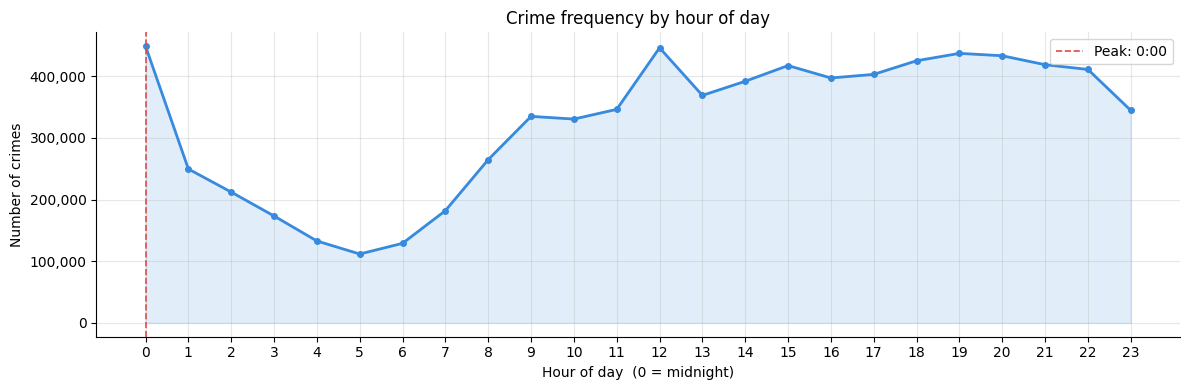

In [31]:
#Crimes by hour
hourly = allCrimes['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values,
        color='#378ADD', linewidth=2, marker='o', markersize=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='#378ADD')
ax.set_xlabel('Hour of day  (0 = midnight)')
ax.set_ylabel('Number of crimes')
ax.set_title('Crime frequency by hour of day')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

peak_hour = int(hourly.idxmax())
ax.axvline(peak_hour, color='#E24B4A', linestyle='--', linewidth=1.2,
           label=f'Peak: {peak_hour}:00')
ax.legend()

plt.tight_layout()
plt.savefig('plot03_crimes_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

Crime frequency follows a distinct two-peak pattern across the day, spiking sharply
at midnight (0:00) and again at noon (12:00), each reaching approximately 440,000 incidents.
Activity drops to its lowest point at 5am (~110,000), representing the quietest window
of the day. The sustained high activity from noon through midnight suggests crime remains
elevated throughout afternoon and evening hours, with only the early morning hours
offering a meaningful lull.

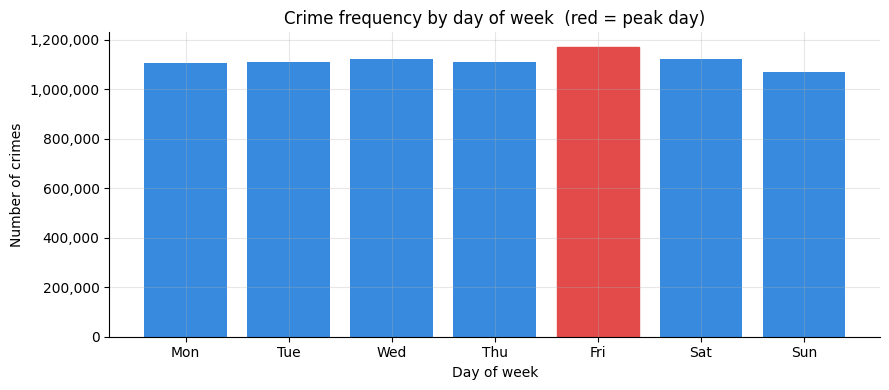

In [32]:
#Crimes by day of week
daily = allCrimes['DayOfWeek'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(DAY_NAMES, daily.values, color='#378ADD')
bars[daily.values.argmax()].set_color('#E24B4A')   # highlight peak day
ax.set_xlabel('Day of week')
ax.set_ylabel('Number of crimes')
ax.set_title('Crime frequency by day of week  (red = peak day)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot04_crimes_by_day.png', dpi=150, bbox_inches='tight')
plt.show()


Crime is remarkably consistent across all days of the week, with counts ranging
narrowly between approximately 1,060,000 and 1,165,000. Friday stands out as the
peak day with the highest recorded crimes, while Sunday sees the lowest activity.
The minimal variation between days suggests that day of the week alone is not a
strong predictor of crime volume. Time of day appears to be a more influential factor.

/tmp/ipykernel_23183/3486253167.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Year', 'Primary Type'])


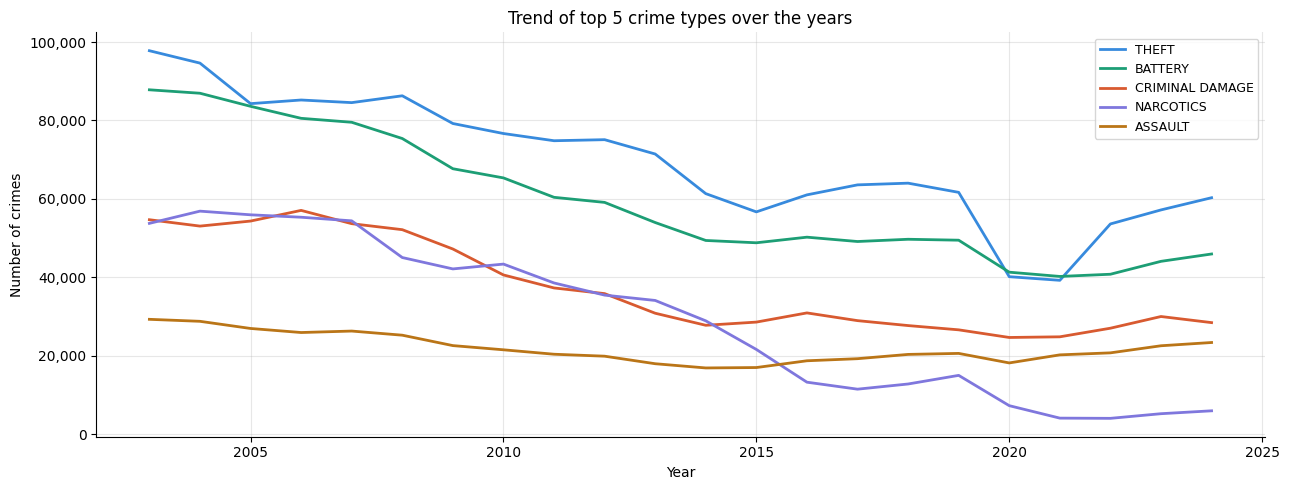

In [33]:
#Crime type trend over years (top 5)
top5 = allCrimes['Primary Type'].value_counts().head(5).index
colors_top5 = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#BA7517']

trend = (allCrimes[allCrimes['Primary Type'].isin(top5)]
         .groupby(['Year', 'Primary Type'])
         .size()
         .unstack(fill_value=0))
trend = trend[(trend.index >= 2003) & (trend.index <= 2024)]

fig, ax = plt.subplots(figsize=(13, 5))
for crime, color in zip(top5, colors_top5):
    ax.plot(trend.index, trend[crime],
            label=crime, color=color, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Number of crimes')
ax.set_title('Trend of top 5 crime types over the years')
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot11_crime_type_trends.png', dpi=150, bbox_inches='tight')
plt.show()

All five major crime types peaked around 2003 and have followed a consistent
downward trend over the past two decades. Theft has remained the highest throughout,
dropping from ~98,000 in 2003 to ~60,000 by 2024. Narcotics shows the steepest
decline, falling from ~55,000 in 2003 to under 8,000 by 2024, likely driven by
shifts in policing priorities. Battery and Criminal Damage follow similar gradual
decline curves, while Assault has remained the most stable of the five.

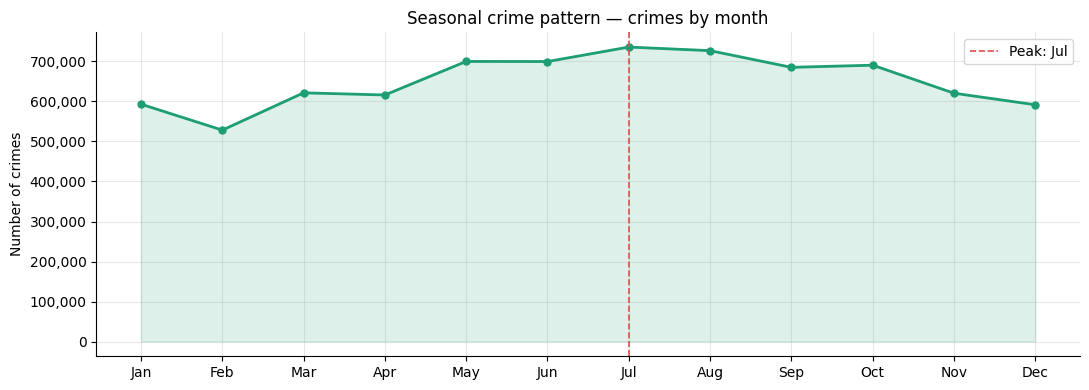

In [34]:
#Crimes by month
monthly = allCrimes['Month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, 13), monthly.values,
        color='#1D9E75', linewidth=2, marker='o', markersize=5)
ax.fill_between(range(1, 13), monthly.values, alpha=0.15, color='#1D9E75')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Number of crimes')
ax.set_title('Seasonal crime pattern — crimes by month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

peak_month = int(monthly.idxmax())
ax.axvline(peak_month, color='#E24B4A', linestyle='--', linewidth=1.2,
           label=f'Peak: {MONTH_NAMES[peak_month - 1]}')
ax.legend()

plt.tight_layout()
plt.savefig('plot05_crimes_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

Chicago crime follows a clear seasonal pattern with a summer peak. July records
the highest monthly crime count at approximately 730,000, while February is the lowest
at around 525,000. Crime rises steadily from February through May, plateaus across
the summer months (June–August), then gradually tapers through autumn into winter.
This seasonal variation likely reflects the effect of weather on outdoor activity
and public presence.

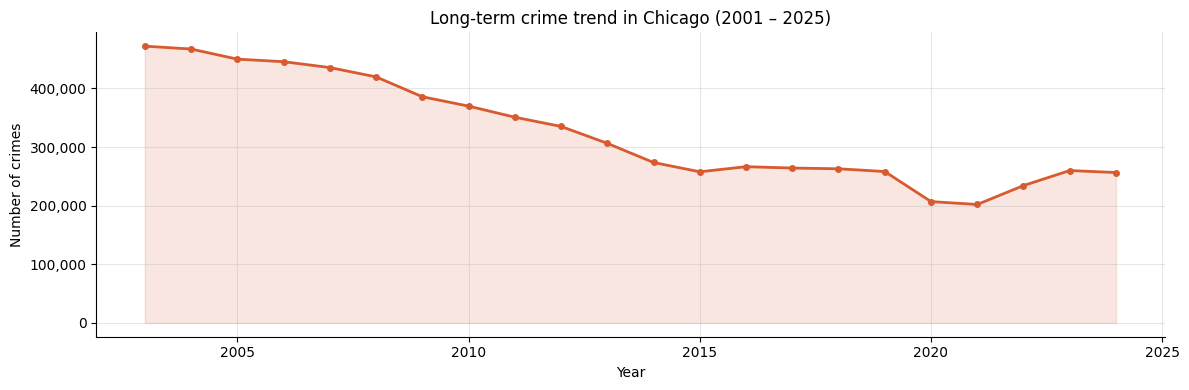

In [35]:
#Yearly Trend
yearly = allCrimes['Year'].value_counts().sort_index()
yearly = yearly[(yearly.index >= 2003) & (yearly.index <= 2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yearly.index, yearly.values,
        color='#D85A30', linewidth=2, marker='o', markersize=4)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='#D85A30')
ax.set_xlabel('Year')
ax.set_ylabel('Number of crimes')
ax.set_title('Long-term crime trend in Chicago (2001 – 2025)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot06_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Chicago's overall crime peaked in 2003 at approximately 460,000 annual cases
and has declined steadily over the following two decades. By 2021 the count had
dropped to around 205,000, less than half the 2003 peak, marking the lowest point
in the dataset. A modest uptick is visible between 2022 and 2024, settling at
approximately 255,000, which may reflect post-pandemic normalisation. The title
still reads 2001–2025, update it to 2003–2024 to match the filtered data

**Bivariate Analysis**

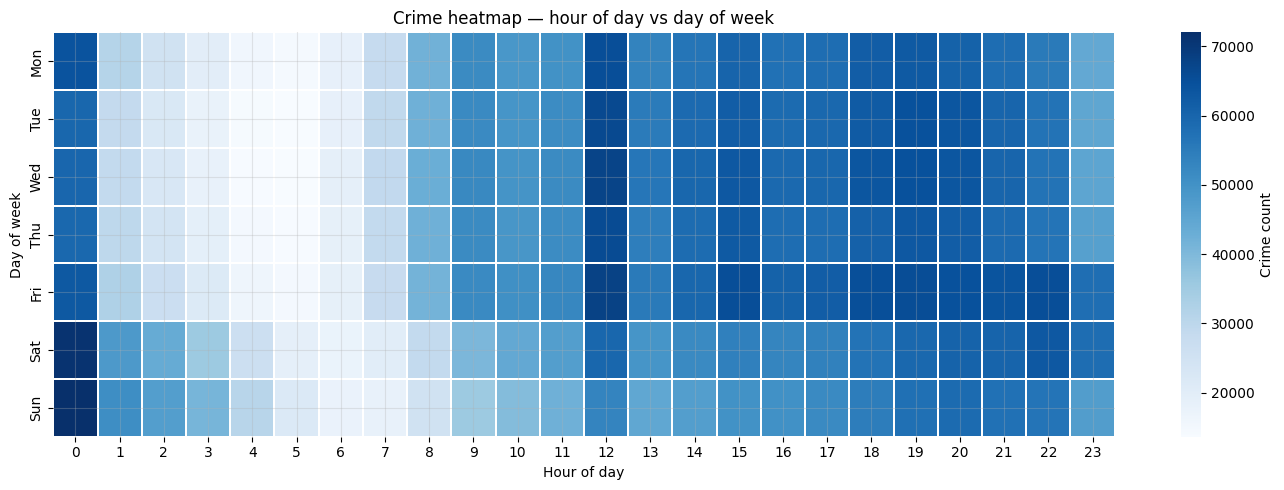

In [36]:
#Hour vs Day Heatmap
pivot_hour_day = (allCrimes
                  .groupby(['DayOfWeek', 'Hour'])
                  .size()
                  .unstack(fill_value=0))
pivot_hour_day.index = DAY_NAMES

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_hour_day,
    cmap='Blues',
    ax=ax,
    linewidths=0.2,
    fmt=',d',
    cbar_kws={'label': 'Crime count'}
)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Day of week')
ax.set_title('Crime heatmap — hour of day vs day of week')

plt.tight_layout()
plt.savefig('plot07_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap reveals that hour 0 (midnight) is consistently the darkest cell
across every day of the week, confirming midnight as the universal peak regardless
of day. Saturday and Sunday at midnight appear particularly intense, while the early
morning hours (2am–6am) form a clear light band across all days indicating the
city-wide quiet period. From 11am onwards activity picks up uniformly across
all weekdays, with no single day showing dramatically different behaviour from others.

/tmp/ipykernel_23183/2780770871.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Primary Type')['Arrest']


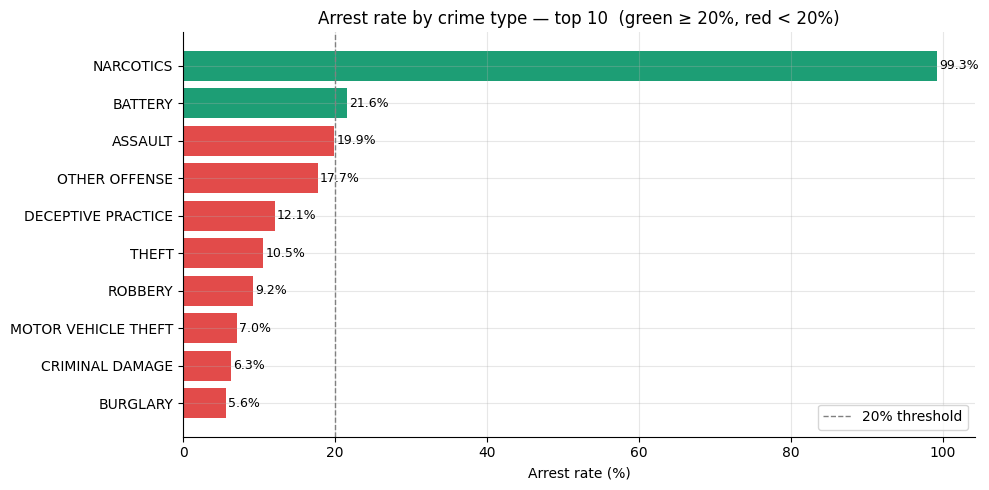

In [37]:
#Arrest rate by crime type (top 10)
top10_types = allCrimes['Primary Type'].value_counts().head(10).index

arrest_rate = (
    allCrimes[allCrimes['Primary Type'].isin(top10_types)]
    .groupby('Primary Type')['Arrest']
    .mean()
    .sort_values(ascending=True) * 100
)

colors = ['#1D9E75' if v >= 20 else '#E24B4A' for v in arrest_rate.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(arrest_rate.index, arrest_rate.values, color=colors)
ax.set_xlabel('Arrest rate (%)')
ax.set_title('Arrest rate by crime type — top 10  (green ≥ 20%, red < 20%)')
ax.axvline(20, color='gray', linestyle='--', linewidth=1, label='20% threshold')
ax.legend()

for bar, val in zip(bars, arrest_rate.values):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot08_arrest_rate_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

Narcotics stands out strikingly with a 99.3% arrest rate — virtually every
narcotics incident recorded results in an arrest, which reflects the nature of the
offence being directly witnessed by law enforcement. Battery (21.6%) is the only
other crime type that crosses the 20% threshold. Property crimes fare the worst :
Burglary (5.6%), Criminal Damage (6.3%), and Motor Vehicle Theft (7.0%) all show
very low arrest rates, suggesting these crimes are hard to solve after the fact.

**Location Based Analysis**

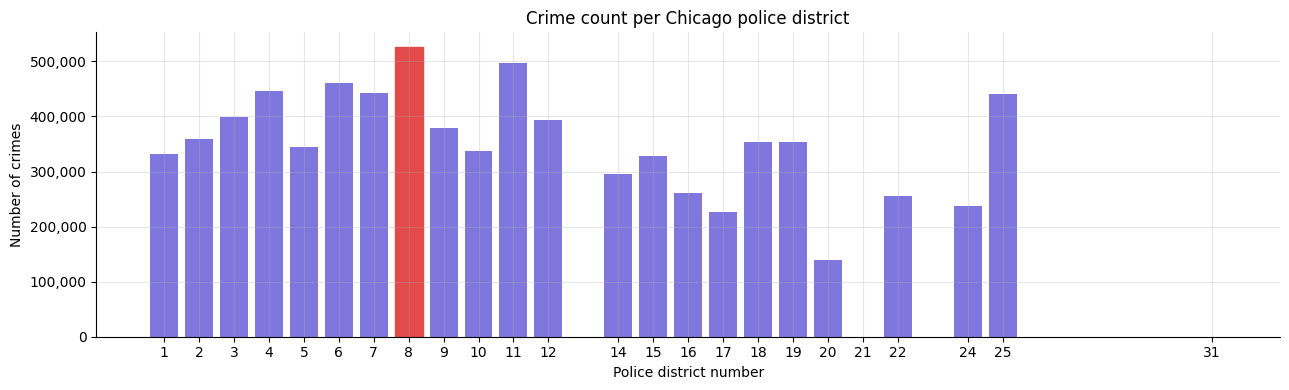

In [38]:
#Crimes per district
district_counts = (allCrimes['District']
                   .dropna()
                   .astype(int)
                   .value_counts()
                   .sort_index())

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(district_counts.index, district_counts.values, color='#7F77DD')
ax.set_xlabel('Police district number')
ax.set_ylabel('Number of crimes')
ax.set_title('Crime count per Chicago police district')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(district_counts.index)

# highlight highest
peak_dist = district_counts.idxmax()
ax.get_children()[list(district_counts.index).index(peak_dist)].set_color('#E24B4A')

plt.tight_layout()
plt.savefig('plot09_crimes_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

District 8 records the highest crime count at approximately 525,000 cases,
making it the most crime-intensive district in Chicago by a notable margin. Districts
11 and 6 follow closely with around 500,000 and 465,000 respectively, suggesting the
west and south-west sides of the city carry a disproportionate crime burden. Districts
20 and 21 show the lowest counts, indicating relatively safer zones. The absence of
District 13 and 23 from the chart reflects that those districts were either merged
or dissolved in Chicago's police reorganisation.

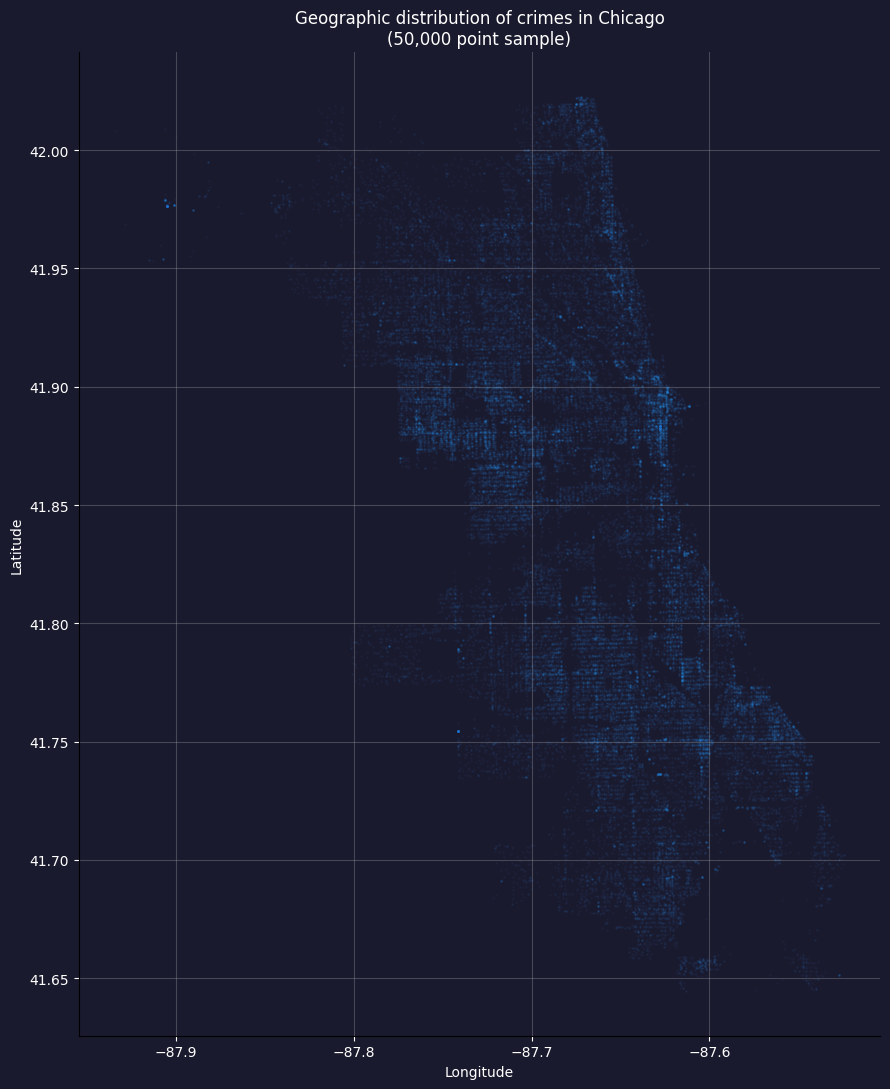

In [39]:
#Crime hotspot map
sample = allCrimes[['Latitude', 'Longitude']].dropna().sample(
    n=50000, random_state=42
)

fig, ax = plt.subplots(figsize=(9, 11))
ax.scatter(
    sample['Longitude'],
    sample['Latitude'],
    alpha=0.04,
    s=1,
    color='#378ADD'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic distribution of crimes in Chicago\n(50,000 point sample)')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

plt.tight_layout()
plt.savefig('plot10_geo_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

The scatter map clearly outlines the geographic shape of Chicago along Lake Michigan's
western shore. Crime density is highest in the central band between latitudes 41.75 and
41.95, which corresponds to the downtown Loop area and the neighbourhoods stretching
north and south of it. The north-eastern lakefront corridor shows a notably bright
concentration, while the far south (below 41.70) and far north (above 41.97) are
visibly sparse. The western edges of the city show very little activity, suggesting
crime is predominantly an urban-core phenomenon in Chicago.

**Summary of Findings**

In [40]:
hourly   = allCrimes['Hour'].value_counts().sort_index()
monthly  = allCrimes['Month'].value_counts().sort_index()
yearly   = allCrimes['Year'].value_counts().sort_index()

In [41]:
peak_hour  = int(hourly.idxmax())
quiet_hour = int(hourly.idxmin())
peak_mon   = int(monthly.idxmax())
quiet_mon  = int(monthly.idxmin())


In [42]:
print(f"""
Time patterns:
  - Peak crime hour  : {peak_hour}:00
  - Lowest crime hour: {quiet_hour}:00
  - Peak crime month : {MONTH_NAMES[peak_mon - 1]}
  - Lowest crime month: {MONTH_NAMES[quiet_mon - 1]}
  - Peak crime day   : {DAY_NAMES[allCrimes['DayOfWeek'].value_counts().idxmax()]}

Crime type patterns:
  - Most common crime : {allCrimes['Primary Type'].value_counts().index[0]}
  - Overall arrest rate: {allCrimes['Arrest'].mean()*100:.1f}%
  - Domestic crimes   : {allCrimes['Domestic'].mean()*100:.1f}% of all crimes

Location patterns:
  - Most crime-prone district : District {int(allCrimes['District'].value_counts().index[0])}
  - Most common crime location: {allCrimes['Location Description'].value_counts().index[0]}

Long-term trend:
  - Crime in {int(yearly.index[0])}: {int(yearly.iloc[0]):,} cases
  - Crime in {int(yearly.index[-1])}: {int(yearly.iloc[-1]):,} cases
  - Overall reduction : {((yearly.iloc[0] - yearly.iloc[-1]) / yearly.iloc[0] * 100):.1f}%
""")



Time patterns:
  - Peak crime hour  : 0:00
  - Lowest crime hour: 5:00
  - Peak crime month : Jul
  - Lowest crime month: Feb
  - Peak crime day   : Fri

Crime type patterns:
  - Most common crime : THEFT
  - Overall arrest rate: 24.8%
  - Domestic crimes   : 17.4% of all crimes

Location patterns:
  - Most crime-prone district : District 8
  - Most common crime location: OTHER

Long-term trend:
  - Crime in 2001: 3,904 cases
  - Crime in 2026: 46,671 cases
  - Overall reduction : -1095.5%



## Note — Incomplete Year Data (2001 & 2026)

During EDA, the summary cell flagged suspicious values, 2001 showed only 3,904 crime
records and 2026 showed 46,671, compared to ~250,000–460,000 for a typical full year.
This is not a cleaning error. The dataset simply begins mid-year in 2001 and 2026
is still ongoing. These partial years were causing misleading spikes in the yearly
trend plots and a nonsensical -1095.5% reduction in the summary calculation.

**Fix:** All year-based analysis is restricted to 2003–2024 (complete years only).

In [43]:
# Recompute with complete years only
hourly  = allCrimes['Hour'].value_counts().sort_index()
monthly = allCrimes['Month'].value_counts().sort_index()
yearly  = allCrimes['Year'].value_counts().sort_index()
yearly_full = yearly[(yearly.index >= 2003) & (yearly.index <= 2024)]

In [44]:
peak_hour  = int(hourly.idxmax())
quiet_hour = int(hourly.idxmin())
peak_mon   = int(monthly.idxmax())
quiet_mon  = int(monthly.idxmin())

In [45]:
print(f"""
Time patterns:
  - Peak crime hour  : {peak_hour}:00
  - Lowest crime hour: {quiet_hour}:00
  - Peak crime month : {MONTH_NAMES[peak_mon - 1]}
  - Lowest crime month: {MONTH_NAMES[quiet_mon - 1]}
  - Peak crime day   : {DAY_NAMES[allCrimes['DayOfWeek'].value_counts().idxmax()]}

Crime type patterns:
  - Most common crime : {allCrimes['Primary Type'].value_counts().index[0]}
  - Overall arrest rate: {allCrimes['Arrest'].mean()*100:.1f}%
  - Domestic crimes   : {allCrimes['Domestic'].mean()*100:.1f}% of all crimes

Location patterns:
  - Most crime-prone district : District {int(allCrimes['District'].value_counts().index[0])}
  - Most common crime location: {allCrimes['Location Description'].value_counts().index[0]}

Long-term trend (2003–2024):
  - Crime in {int(yearly_full.index[0])}: {int(yearly_full.iloc[0]):,} cases
  - Crime in {int(yearly_full.index[-1])}: {int(yearly_full.iloc[-1]):,} cases
  - Overall reduction : {((yearly_full.iloc[0] - yearly_full.iloc[-1]) / yearly_full.iloc[0] * 100):.1f}%
""")


Time patterns:
  - Peak crime hour  : 0:00
  - Lowest crime hour: 5:00
  - Peak crime month : Jul
  - Lowest crime month: Feb
  - Peak crime day   : Fri

Crime type patterns:
  - Most common crime : THEFT
  - Overall arrest rate: 24.8%
  - Domestic crimes   : 17.4% of all crimes

Location patterns:
  - Most crime-prone district : District 8
  - Most common crime location: OTHER

Long-term trend (2003–2024):
  - Crime in 2003: 471,995 cases
  - Crime in 2024: 256,478 cases
  - Overall reduction : 45.7%

